# **Model Evaluation & Statistical Comparison**
**Decodelabs Internship | Week 2 | Task 5 (Part 3)**

---
## What this notebook does
This is where I performed the final evaluation of all trained models on the held-out
**test set**.


In [1]:
import sys, os
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
from configs.config import (
    RAW_FILE, IDS_MAP_FILE, INTERIM_FILE, PROCESSED_FILE,
    TRAIN_FILE, VAL_FILE, TEST_FILE,
    FIGURES_DIR, TABLES_DIR, PAPER_FIG_DIR, PAPER_TAB_DIR,
    RANDOM_SEED, TARGET_COL, PATIENT_ID_COL, MEDICATION_COLS,
    AGE_ORDER, icd9_to_category, COLORS, ensure_dirs
)
from src.plot_utils import set_plot_style, save_figure, save_table
ensure_dirs()
set_plot_style()
print("Config loaded. Seed:", RANDOM_SEED)

Config loaded. Seed: 42


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve,
                              confusion_matrix, classification_report,
                              f1_score, recall_score, precision_score)
from sklearn.model_selection import StratifiedKFold
from scipy import stats
from src.eval_utils import compute_metrics, bootstrap_metric, compare_models_table
import warnings, joblib, os
warnings.filterwarnings("ignore")

# ── Load data ──────────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_FILE)
val_df   = pd.read_csv(VAL_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]
X_val   = val_df.drop(columns=[TARGET_COL])
y_val   = val_df[TARGET_COL]
X_test  = test_df.drop(columns=[TARGET_COL])
y_test  = test_df[TARGET_COL]

print(f"Train : {len(X_train):,} rows | {y_train.mean()*100:.1f}% positive")
print(f"Val   : {len(X_val):,} rows | {y_val.mean()*100:.1f}% positive")
print(f"Test  : {len(X_test):,} rows | {y_test.mean()*100:.1f}% positive")

Train : 48,990 rows | 7.5% positive
Val   : 10,498 rows | 7.5% positive
Test  : 10,499 rows | 7.2% positive


## Retraining all models on train+val combined

For the final test-set evaluation, I trained on ALL available labelled data (train + validation combined). The test set remains completely unseen.

In [3]:
# This is a standard practice: once I've selected my best model using the validation set, I retrain on train+val for maximum training data.

import imblearn
from imblearn.over_sampling import SMOTE

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

print(f"Train+Val size: {len(X_trainval):,} rows | {y_trainval.mean()*100:.1f}% positive")

# Apply SMOTE to the combined training set
try:
    smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
    X_tv_res, y_tv_res = smote.fit_resample(X_trainval, y_trainval)
    print(f"After SMOTE   : {len(X_tv_res):,} rows | {y_tv_res.mean()*100:.1f}% positive")
except Exception as e:
    print(f"SMOTE failed ({e}), using class_weight instead.")
    X_tv_res, y_tv_res = X_trainval, y_trainval

Train+Val size: 59,488 rows | 7.5% positive
After SMOTE   : 110,100 rows | 50.0% positive


In [4]:
# Train all models on the full train+val set
models = {}

# Dummy baseline
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(X_tv_res, y_tv_res)
models["Dummy Classifier"] = dummy

# Logistic Regression
lr = LogisticRegression(class_weight="balanced", max_iter=2000,
                         random_state=RANDOM_SEED, solver="lbfgs", C=1.0)
lr.fit(X_tv_res, y_tv_res)
models["Logistic Regression"] = lr

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=10,
                             min_samples_leaf=20, max_features="sqrt",
                             class_weight="balanced_subsample",
                             random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_tv_res, y_tv_res)
models["Random Forest"] = rf

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=300, max_depth=4,
                                 learning_rate=0.05, subsample=0.8,
                                 min_samples_leaf=20, random_state=RANDOM_SEED)
gb.fit(X_tv_res, y_tv_res)
models["Gradient Boosting"] = gb

# XGBoost (if available)
try:
    from xgboost import XGBClassifier
    scale_w = (y_tv_res == 0).sum() / (y_tv_res == 1).sum()
    xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         scale_pos_weight=scale_w, eval_metric="auc",
                         random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)
    xgb.fit(X_tv_res, y_tv_res)
    models["XGBoost"] = xgb
    print("XGBoost trained.")
except ImportError:
    print("XGBoost not available.")

print(f"\nModels trained: {list(models.keys())}")

XGBoost trained.

Models trained: ['Dummy Classifier', 'Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


## Final test-set evaluation

In [5]:
test_results = []
model_probs  = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except Exception:
        y_prob = None

    metrics = compute_metrics(y_test, y_pred, y_prob, name)
    test_results.append(metrics)
    if y_prob is not None:
        model_probs[name] = y_prob

print("=== Final Test Set Results ===")
results_df = compare_models_table(test_results)
display_cols = ["Accuracy", "Balanced Acc.", "Precision", "Recall",
                "F1-Score", "ROC-AUC", "Avg. Precision"]
print(results_df[display_cols].to_string())
save_table(results_df, "09_final_test_results.csv", TABLES_DIR)
save_table(results_df, "09_final_test_results.csv", PAPER_TAB_DIR)

=== Final Test Set Results ===
                     Accuracy  Balanced Acc.  Precision  Recall  F1-Score  ROC-AUC  Avg. Precision
Model                                                                                             
Gradient Boosting      0.9282         0.5005     0.2500  0.0013    0.0026   0.6855          0.1513
XGBoost                0.9284         0.5000     0.0000  0.0000    0.0000   0.6836          0.1508
Random Forest          0.8852         0.5492     0.1713  0.1569    0.1638   0.6789          0.1385
Logistic Regression    0.6497         0.6174     0.1148  0.5798    0.1916   0.6617          0.1403
Dummy Classifier       0.9284         0.5000     0.0000  0.0000    0.0000   0.5000          0.0716
  Table  saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\tables\09_final_test_results.csv
  Table  saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\paper_or_report\tables\09_final_tes

'c:\\Users\\Peter\\Documents\\EXTRA-CURRICULA\\Internship\\Decodelab\\diabetes_readmission\\paper_or_report\\tables\\09_final_test_results.csv'

## Bootstrap 95% confidence intervals

Bootstrap CI tells me how reliable each point estimate is. A narrow CI means the test-set estimate is stable. A wide CI means I need more data or the model is highly variable.

In [7]:
print("=== Bootstrap 95% CI for ROC-AUC (1,000 resamples) ===\n")

ci_rows = []
for name, y_prob in model_probs.items():
    if name == "Dummy Classifier":
        continue
    est, lo, hi = bootstrap_metric(
        y_test, y_prob, roc_auc_score,
        n_bootstrap=1000, seed=RANDOM_SEED
    )
    ci_rows.append({
        "Model": name,
        "ROC-AUC": round(est, 4),
        "95% CI lower": round(lo, 4),
        "95% CI upper": round(hi, 4),
        "CI width": round(hi - lo, 4)
    })
    print(f"  {name:22s}: {est:.4f}  [{lo:.4f}, {hi:.4f}]")

ci_df = pd.DataFrame(ci_rows).set_index("Model")
save_table(ci_df, "09_bootstrap_confidence_intervals.csv", TABLES_DIR)

=== Bootstrap 95% CI for ROC-AUC (1,000 resamples) ===

  Logistic Regression   : 0.6617  [0.6418, 0.6813]
  Random Forest         : 0.6789  [0.6603, 0.6997]
  Gradient Boosting     : 0.6855  [0.6662, 0.7049]
  XGBoost               : 0.6836  [0.6649, 0.7024]
  Table  saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\tables\09_bootstrap_confidence_intervals.csv


'c:\\Users\\Peter\\Documents\\EXTRA-CURRICULA\\Internship\\Decodelab\\diabetes_readmission\\reports\\tables\\09_bootstrap_confidence_intervals.csv'

Wider CI = more uncertainty. Narrower CI = more reliable estimate. With ~10,000+ test rows, these CIs should be reasonably tight.

## ROC curves comparison

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\09_roc_and_pr_curves.png
  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\paper_or_report\figures\09_roc_and_pr_curves.png


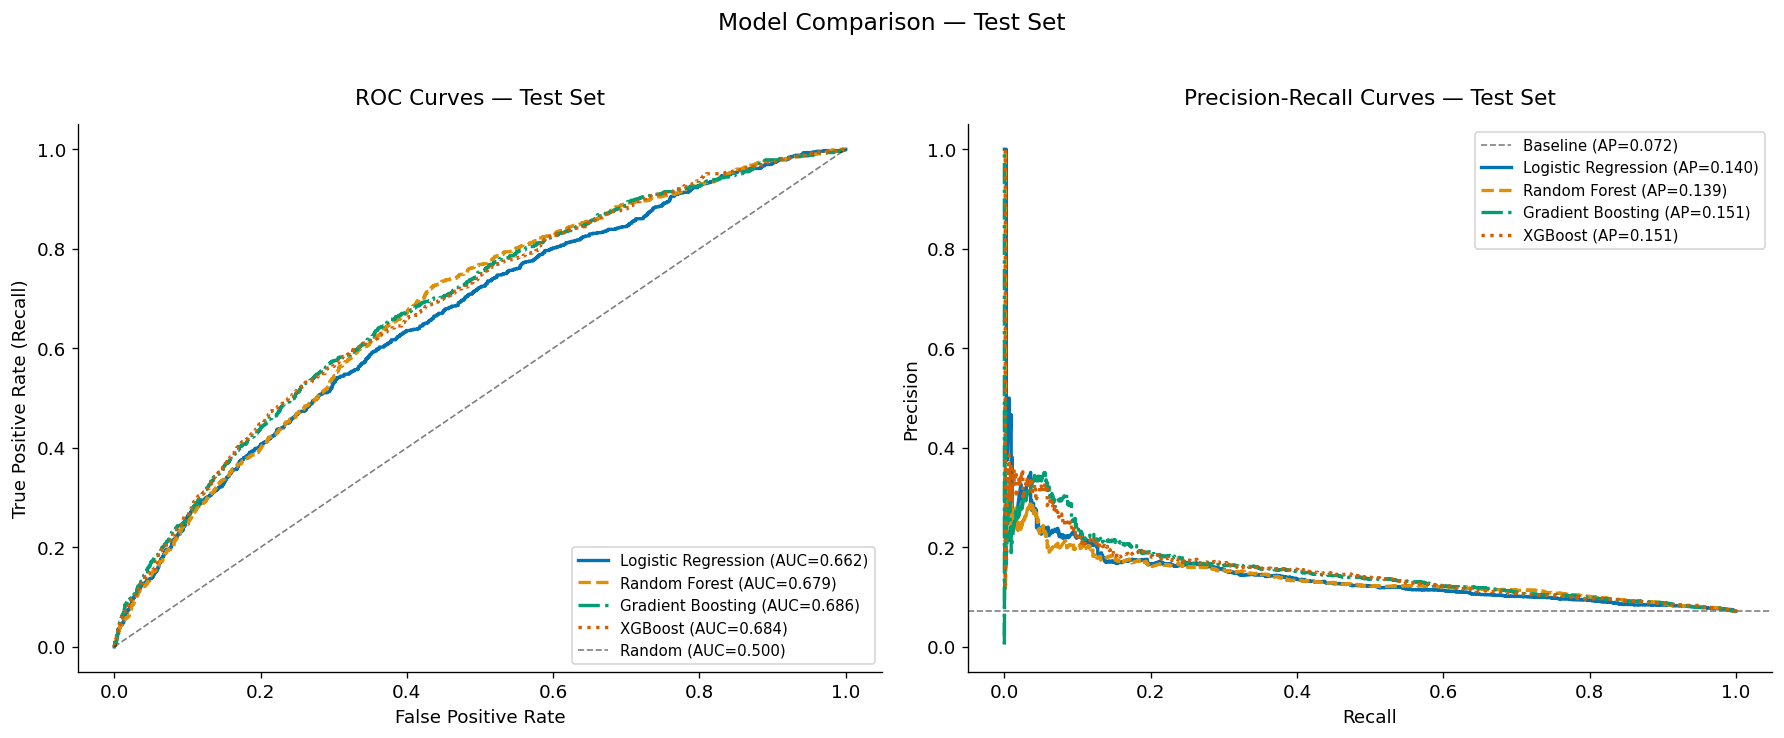

In [8]:
from src.plot_utils import plot_roc_curves, plot_pr_curves

# Filter to non-dummy models
eval_probs = {k: v for k, v in model_probs.items() if k != "Dummy Classifier"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_roc_curves(eval_probs, y_test, ax=axes[0])
plot_pr_curves(eval_probs,  y_test, ax=axes[1])

fig.suptitle("Model Comparison — Test Set", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "09_roc_and_pr_curves.png", FIGURES_DIR)
save_figure(fig, "09_roc_and_pr_curves.png", PAPER_FIG_DIR)
plt.show()

PR-AUC is more informative than ROC-AUC when classes are imbalanced. A PR-AUC of 0.3 on an 11%-prevalence dataset is much better than it looks.

## Confusion matrices for all models

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\09_confusion_matrices.png
  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\paper_or_report\figures\09_confusion_matrices.png


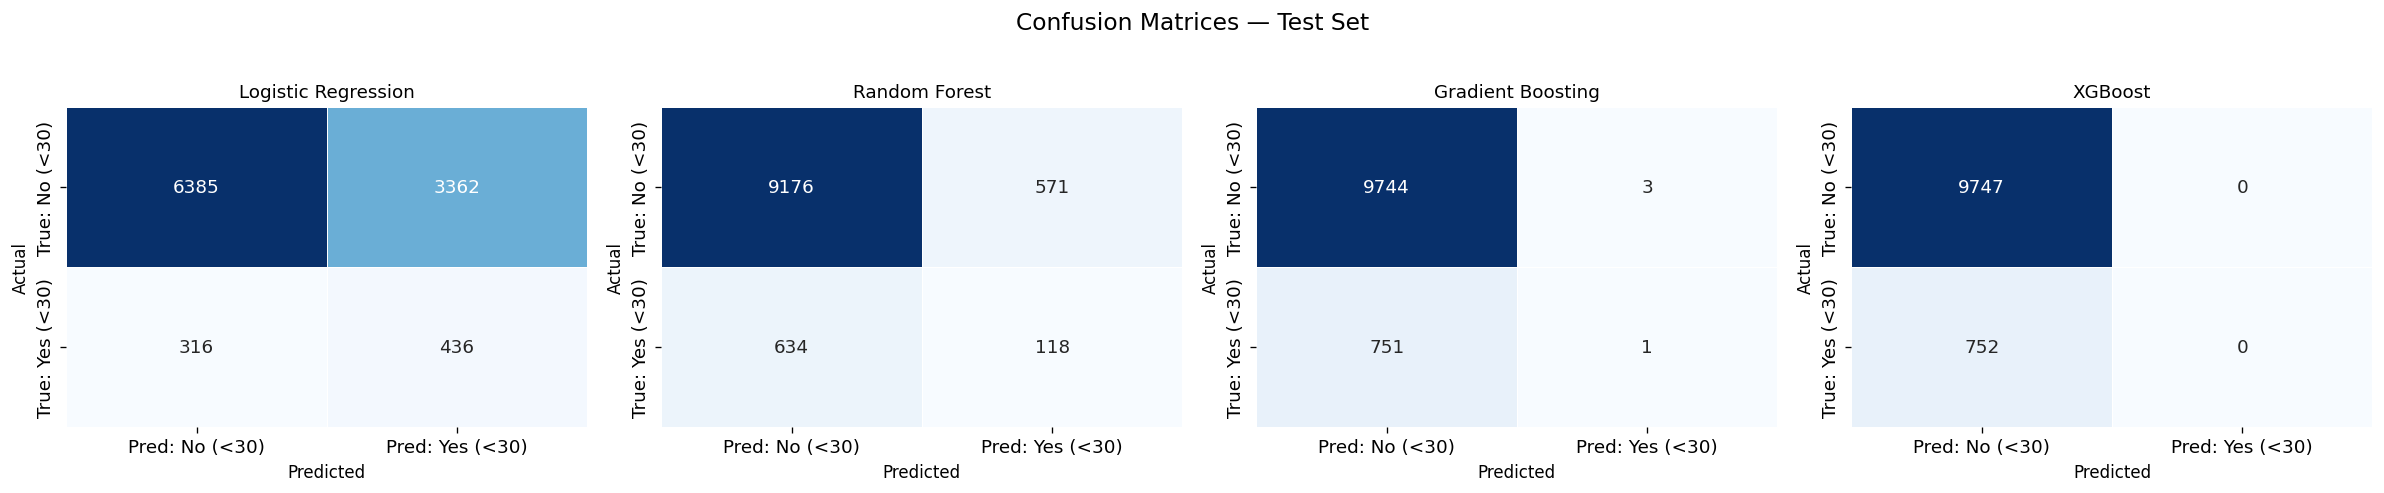

In [9]:
from src.plot_utils import plot_confusion_matrix

real_models = {k: v for k, v in models.items() if k != "Dummy Classifier"}
n_models    = len(real_models)

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, real_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(cm, ax, title=name)

fig.suptitle("Confusion Matrices — Test Set", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "09_confusion_matrices.png", FIGURES_DIR)
save_figure(fig, "09_confusion_matrices.png", PAPER_FIG_DIR)
plt.show()

## Threshold analysis

The default threshold for classification is 0.5 (predict class 1 if prob >= 0.5). But clinically, missing a readmission (False Negative) is much costlier than a false alarm (False Positive). We might prefer a lower threshold. I analysed precision and recall at different thresholds for the best model.

In [10]:
# Identify best model by ROC-AUC
best_name = results_df["ROC-AUC"].astype(float).idxmax()
print(f"Best model by ROC-AUC: {best_name}")

y_prob_best = model_probs[best_name]

print(f"\n=== Precision / Recall at Different Thresholds ({best_name}) ===")
print(f"  {'Threshold':10s} {'Precision':12s} {'Recall':10s} {'F1':8s} {'N flagged':10s}")

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
threshold_rows = []
for thr in thresholds:
    y_pred_thr = (y_prob_best >= thr).astype(int)
    prec = precision_score(y_test, y_pred_thr, zero_division=0)
    rec  = recall_score(y_test, y_pred_thr, zero_division=0)
    f1   = f1_score(y_test, y_pred_thr, zero_division=0)
    n    = y_pred_thr.sum()
    print(f"  {thr:<10.2f} {prec:<12.3f} {rec:<10.3f} {f1:<8.3f} {n:,}")
    threshold_rows.append({"threshold": thr, "precision": prec, "recall": rec,
                            "f1": f1, "n_flagged": n})

thr_df = pd.DataFrame(threshold_rows)
save_table(thr_df.set_index("threshold"), "09_threshold_analysis.csv", TABLES_DIR)
print()
print("For a clinical screening tool prioritising Recall, a lower threshold is preferable.")
print("Final threshold choice should involve clinical stakeholders.")

Best model by ROC-AUC: Gradient Boosting

=== Precision / Recall at Different Thresholds (Gradient Boosting) ===
  Threshold  Precision    Recall     F1       N flagged 
  0.30       0.304        0.064      0.105    158
  0.35       0.292        0.028      0.051    72
  0.40       0.219        0.009      0.018    32
  0.45       0.200        0.003      0.005    10
  0.50       0.250        0.001      0.003    4
  0.55       0.000        0.000      0.000    0
  0.60       0.000        0.000      0.000    0
  Table  saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\tables\09_threshold_analysis.csv

For a clinical screening tool prioritising Recall, a lower threshold is preferable.
Final threshold choice should involve clinical stakeholders.


## McNemar's test: are models significantly different?

McNemar's test checks whether two classifiers make significantly different errors on the same test set. It operates on the contingency table of correct/incorrect predictions between two models. A significant result (p < 0.05) means the models are genuinely different, not just reflecting random variation.

In [11]:
from scipy.stats import chi2_contingency

model_names = list(real_models.keys())
model_preds = {n: m.predict(X_test) for n, m in real_models.items()}

print("=== McNemar's Test: Pairwise Model Comparison ===")
print(f"  (p < 0.05 means the two models make significantly different errors)\n")

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        name_a = model_names[i]
        name_b = model_names[j]
        pred_a = model_preds[name_a]
        pred_b = model_preds[name_b]
        
        # Contingency table: correct/incorrect for each model
        correct_a = (pred_a == y_test.values)
        correct_b = (pred_b == y_test.values)
        
        # b = A wrong, B correct; c = A correct, B wrong
        b = ((~correct_a) & correct_b).sum()
        c = (correct_a & (~correct_b)).sum()
        
        # McNemar's statistic (continuity-corrected)
        if b + c > 0:
            chi2 = (abs(b - c) - 1)**2 / (b + c)
            # chi2 follows chi2(1) under H0
            pval = 1 - stats.chi2.cdf(chi2, df=1)
        else:
            chi2, pval = 0, 1.0
        
        sig = "✓ SIGNIFICANT" if pval < 0.05 else "  not significant"
        print(f"  {name_a} vs {name_b}")
        print(f"    chi2={chi2:.3f}  p={pval:.4f}  {sig}")
        print()

=== McNemar's Test: Pairwise Model Comparison ===
  (p < 0.05 means the two models make significantly different errors)

  Logistic Regression vs Random Forest
    chi2=1893.642  p=0.0000  ✓ SIGNIFICANT

  Logistic Regression vs Gradient Boosting
    chi2=2251.958  p=0.0000  ✓ SIGNIFICANT

  Logistic Regression vs XGBoost
    chi2=2252.666  p=0.0000  ✓ SIGNIFICANT

  Random Forest vs Gradient Boosting
    chi2=293.904  p=0.0000  ✓ SIGNIFICANT

  Random Forest vs XGBoost
    chi2=296.522  p=0.0000  ✓ SIGNIFICANT

  Gradient Boosting vs XGBoost
    chi2=0.250  p=0.6171    not significant

